<img align="center" src="https://iili.io/3wI8gI.png" style="height:90px" style="width:30px"/>

# First inspection
Import pandas and read the `gapminder_alcohol.csv` file 

Get an overview of the dataset

In [2]:
import pandas as pd

df = pd.read_csv("gapminder_alcohol.csv")

# Rename columns

- alcconsumption --> alc_consump
- incomeperperson --> inc_pp
- employrate --> emp_rate

save the changes

In [4]:
df.rename(columns={"alcconsumption":"alc_consump","incomeperperson": "inc_pp", "employrate": "emp_rate"},inplace=True)

# set new index

check that the country column has unique values, and then set it as the new index

In [6]:
df

,country,alc_consump,inc_pp,suicideper100th,emp_rate,urbanrate
0,Afghanistan,0.03,NaN,6.684385,55.700001,24.04
1,Albania,7.29,1914.996551,7.699330,51.400002,46.72
2,Algeria,0.69,2231.993335,4.848770,50.500000,65.22
3,Andorra,10.17,21943.339900,5.362179,NaN,88.92
4,Angola,5.57,1381.004268,14.554677,75.699997,56.70
...,...,...,...,...,...,...
208,Vietnam,3.91,722.807559,11.653322,71.000000,27.84
209,West Bank and Gaza,NaN,NaN,NaN,32.000000,71.90
210,"Yemen, Rep.",0.20,610.357367,6.265789,39.000000,30.64
211,Zambia,3.56,432.226337,12.019036,61.000000,35.42


In [8]:
df["country"].nunique() == len(df["country"])

True

In [10]:
df.set_index("country",inplace=True)

# richest/poorest? drunkest/soberest?

- Which are the top & bottom three richest/poorest countries
- Which are the top & bottom three alcohol consuming countries


In [12]:
df

,alc_consump,inc_pp,suicideper100th,emp_rate,urbanrate
country,,,,,
Afghanistan,0.03,NaN,6.684385,55.700001,24.04
Albania,7.29,1914.996551,7.699330,51.400002,46.72
Algeria,0.69,2231.993335,4.848770,50.500000,65.22
Andorra,10.17,21943.339900,5.362179,NaN,88.92
Angola,5.57,1381.004268,14.554677,75.699997,56.70
...,...,...,...,...,...
Vietnam,3.91,722.807559,11.653322,71.000000,27.84
West Bank and Gaza,NaN,NaN,NaN,32.000000,71.90
"Yemen, Rep.",0.20,610.357367,6.265789,39.000000,30.64


In [ ]:
top3_alcohol = (
    df.nlargest(3, "alc_consump")[["Country", "Alcohol_consumption"]]
)
bot3_alcohol = (
    df.nsmallest(3, "alc_consump")[["Country", "Alcohol_consumption"]]
)
top3_money = (
    df.nlargest(3, "alc_consump")[["Country", "inc_pp"]]
)
bot3_money = (
    df.nsmallest(3, "alc_consump")[["Country", "inc_pp"]]
)


# corr() & heatmap()

Which are the top three strongest (in either a positive or negative direction) correlations in the data?

Also, plot an annotated heatmap showing the correlation matrix

In [14]:
corr = df.corr()

<Axes: >

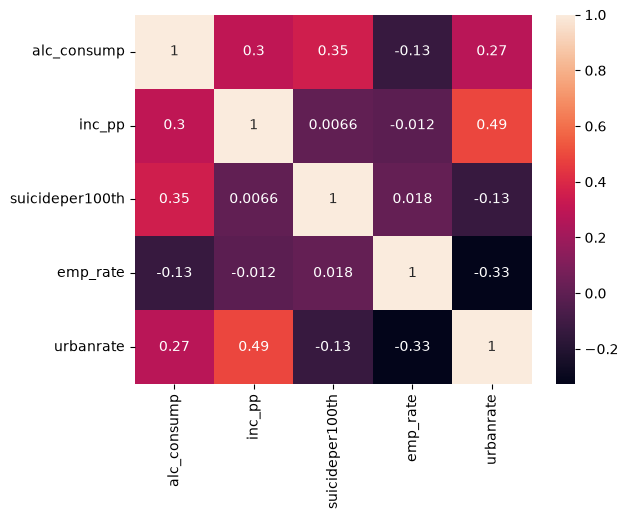

In [15]:
import seaborn as sns
sns.heatmap(corr,annot=True)

# map

Use the prepared dictionary `dct` to map over the index and create a new column named region

What is the mean suicideper100th in Scandinavia?

How much more prevalent are suicides in Finland compared to Denmark?

In [ ]:
dct = {"Denmark":"Scandinavia", "Finland":"Scandinavia", 
       "Iceland":"Scandinavia", "Norway":"Scandinavia", "Sweden":"Scandinavia"}


df["Region"] = df.index.map(dct)

,alc_consump,inc_pp,suicideper100th,emp_rate,urbanrate
country,,,,,
Afghanistan,0.03,NaN,6.684385,55.700001,24.04
Albania,7.29,1914.996551,7.699330,51.400002,46.72
Algeria,0.69,2231.993335,4.848770,50.500000,65.22
Andorra,10.17,21943.339900,5.362179,NaN,88.92
Angola,5.57,1381.004268,14.554677,75.699997,56.70
...,...,...,...,...,...
Vietnam,3.91,722.807559,11.653322,71.000000,27.84
West Bank and Gaza,NaN,NaN,NaN,32.000000,71.90
"Yemen, Rep.",0.20,610.357367,6.265789,39.000000,30.64


In [21]:
df.loc[df["region"] == "Scandinavia"]["suicideper100th"].mean()

np.float64(11.714496968)

# qcut

Use qcut and create 4 groups based of the urbanrate. Label each group and add as a new column named urban_cat

In [ ]:
df["urban_cat"] = pd.qcut(df["urbanrate"],q=4,labels=["cat_1","cat_2","cat_3","cat_4"])


# drop & dropna

first, drop the column region

then use the dropna() method to drop all rows where there are 3 or more NaN-values

*You should end up with a df with 191 rows* 

In [25]:
df

,alc_consump,inc_pp,suicideper100th,emp_rate,urbanrate,region,urban_cat
country,,,,,,,
Afghanistan,0.03,NaN,6.684385,55.700001,24.04,NaN,cat_1
Albania,7.29,1914.996551,7.699330,51.400002,46.72,NaN,cat_2
Algeria,0.69,2231.993335,4.848770,50.500000,65.22,NaN,cat_3
Andorra,10.17,21943.339900,5.362179,NaN,88.92,NaN,cat_4
Angola,5.57,1381.004268,14.554677,75.699997,56.70,NaN,cat_2
...,...,...,...,...,...,...,...
Vietnam,3.91,722.807559,11.653322,71.000000,27.84,NaN,cat_1
West Bank and Gaza,NaN,NaN,NaN,32.000000,71.90,NaN,cat_3
"Yemen, Rep.",0.20,610.357367,6.265789,39.000000,30.64,NaN,cat_1


# plotting

Make a scatterplot with inc_pp on the x-axis and suicideper100th on the y-axis

Make 2 histograms
- 1 showing the distribution of alcohol consumption
- and 1 showing the distribution of employment rate

# Lab finished, well done

___
# Bonus challenge

In this question, you are asked to create a single measure for each country that you will use to rank order them with the goal of identifying the "best" and the "worst" countries. 

A low rank translates to a "good" country

- The country with the lowest alc_consump should be ranked as no. 1
- The country with the highest inc_pp should be ranked as no. 1
- The country with the lowest suicide rate should be ranked as no. 1
- The country with the highest emp_rate should be ranked as no. 1
- The urban rate should not be included in your measure

After having ranked each country along the 4 dimensions included in our metric, you should sum up the total rank for a country. 

Which country is the best/worst according to your metric?

*You can drop all rows with NaN-values*